# 06. Hybrid Intro

В этом notebook мы объединяем несколько источников сигнала вместо выбора только одного подхода.

## Что изучим

- зачем recommender systems часто нужны hybrid-модели;
- как объединять `content-based` и `item-based collaborative filtering` без сложной production-логики;
- как работает weighted interleaving;
- как сравнить hybrid-модель с отдельными компонентами;
- почему гибрид полезен даже тогда, когда одна из моделей слабее по отдельности.


## Интуиция

У разных моделей разные сильные стороны:

- `popularity baseline` стабилен, но почти не персонализирует;
- `content-based` умеет выходить за пределы head-объектов, но зависит от качества признаков;
- `item-based collaborative filtering` использует поведение пользователей, но хуже справляется там, где мало взаимодействий.

Hybrid-подход нужен именно затем, чтобы не выбирать между этими источниками сигнала жёстко, а комбинировать их.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero


In [2]:
from recsys_basics.basic.content_based import ContentBasedRecommender, prepare_genre_text_features
from recsys_basics.basic.hybrid import HybridInterleavingRecommender
from recsys_basics.basic.item_item import ItemBasedCollaborativeRecommender
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_one_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10
HYBRID_WEIGHTS = {"item_based_collaborative": 0.8, "content_based": 0.2}

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()
movies_features_df = prepare_genre_text_features(movies_df)
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

split_result = leave_last_one_out_split(positive_df, min_user_interactions=2)
train_df = split_result.train
test_df = split_result.test
assert_no_user_time_leakage(train_df, test_df)

seen_items_map = build_seen_items_map(train_df)
user_histories = (
    train_df.sort_values(["user_id", "timestamp", "item_id"])
    .groupby("user_id")["item_id"]
    .agg(list)
    .to_dict()
)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Users in evaluation: {len(user_histories):,}")


Train rows: 47,971
Test rows: 608
Users in evaluation: 608


## Готовим отдельные модели

Для гибрида нам нужны источники сигнала, которые уже умеют строить свои списки рекомендаций:

- `content-based` по жанрам;
- `item-based collaborative filtering` по совместным positive interactions.

Popularity baseline тоже оставим как контрольную точку, но в сам hybrid его сейчас не включаем: он нужен именно для честного сравнения, а не для усиления head-bias внутри гибрида.


In [3]:
content_model = ContentBasedRecommender().fit(movies_features_df)
item_based_model = ItemBasedCollaborativeRecommender().fit(train_df)
popularity_model = PopularityRecommender().fit(train_df)

content_recommendations_df = content_model.recommend_many(
    user_histories=user_histories,
    seen_items_map=seen_items_map,
    k=TOP_K,
)
item_based_recommendations_df = item_based_model.recommend_many(
    user_histories=user_histories,
    seen_items_map=seen_items_map,
    k=TOP_K,
)
popularity_recommendations_df = popularity_model.recommend_many(
    user_ids=sorted(user_histories.keys()),
    seen_items_map=seen_items_map,
    k=TOP_K,
)

model_overview = pd.DataFrame(
    {
        "model": ["content-based", "item-based collaborative filtering", "popularity baseline"],
        "n_recommendation_rows": [
            len(content_recommendations_df),
            len(item_based_recommendations_df),
            len(popularity_recommendations_df),
        ],
        "unique_recommended_items": [
            content_recommendations_df["item_id"].nunique(),
            item_based_recommendations_df["item_id"].nunique(),
            popularity_recommendations_df["item_id"].nunique(),
        ],
    }
)
display(model_overview)


,model,n_recommendation_rows,unique_recommended_items
0,content-based,6080,2358
1,item-based collaborative filtering,6080,444
2,popularity baseline,6080,61


## Weighted interleaving: как строится hybrid

Мы используем простой и понятный вариант гибрида: `weighted interleaving`.

Идея такая:

- каждая модель даёт свой ранжированный список;
- мы чередуем элементы из этих списков с учётом весов;
- дубликаты удаляются;
- более сильная модель идёт раньше в каждом раунде, чтобы не портить верх списка только из-за порядка обхода;
- итоговый список сохраняет сильный collaborative сигнал, но не даёт content-based части полностью исчезнуть.

В этом notebook дадим заметно больший вес `item-based collaborative filtering`, потому что в предыдущих шагах он показал лучшее quality metric, чем `content-based` на одних жанрах. Для `top_k=10` это означает, что collaborative-модель должна занимать большую часть списка, а content-based сигнал добавляется осторожно, чтобы hybrid оставался гибридом, но не деградировал из-за слишком слабой компоненты.


In [4]:
hybrid_model = HybridInterleavingRecommender(weights=HYBRID_WEIGHTS)

user_ranked_lists = {}
for user_id in sorted(user_histories.keys()):
    content_list = content_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    item_based_list = item_based_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    user_ranked_lists[int(user_id)] = {
        "item_based_collaborative": item_based_list,
        "content_based": content_list,
    }

hybrid_recommendations_df = hybrid_model.recommend_many(user_ranked_lists=user_ranked_lists, top_k=TOP_K)

display(hybrid_recommendations_df.head(20))


,user_id,item_id,rank
0,1,2918,1
1,1,858,2
2,1,296,3
3,1,1036,4
4,1,589,5
5,1,2762,6
6,1,1200,7
7,1,1221,8
8,1,5657,9
9,1,6990,10


## Пример для одного пользователя

На одном пользователе полезно посмотреть, как именно два списка объединяются в итоговый hybrid-ranking.


In [5]:
sample_user_id = sorted(user_histories.keys())[0]
content_list = user_ranked_lists[int(sample_user_id)]["content_based"]
item_based_list = user_ranked_lists[int(sample_user_id)]["item_based_collaborative"]
hybrid_list = hybrid_model.recommend(user_ranked_lists[int(sample_user_id)], top_k=TOP_K)

sample_lists_df = pd.DataFrame(
    {
        "item-based collaborative filtering": pd.Series(item_based_list),
        "content-based": pd.Series(content_list),
        "hybrid": pd.Series(hybrid_list),
    }
)
display(sample_lists_df)


,item-based collaborative filtering,content-based,hybrid
0,2918,5657,2918
1,858,6990,858
2,296,26340,296
3,1036,108932,1036
4,589,51939,589
5,2762,4818,2762
6,1200,2890,1200
7,1221,82765,1221
8,541,55116,5657
9,2804,7048,6990


## Сравнение моделей по метрикам

Теперь сравним четыре варианта:

- `popularity baseline`;
- `content-based`;
- `item-based collaborative filtering`;
- `hybrid interleaving`.


In [6]:
popularity_metrics = evaluate_ranking_metrics(test_df, popularity_recommendations_df, k=TOP_K)
content_metrics = evaluate_ranking_metrics(test_df, content_recommendations_df, k=TOP_K)
item_based_metrics = evaluate_ranking_metrics(test_df, item_based_recommendations_df, k=TOP_K)
hybrid_metrics = evaluate_ranking_metrics(test_df, hybrid_recommendations_df, k=TOP_K)

comparison_df = pd.DataFrame(
    {
        "model": ["popularity baseline", "content-based", "item-based collaborative filtering", "hybrid interleaving"],
        f"precision@{TOP_K}": [
            popularity_metrics[f"precision@{TOP_K}"].mean(),
            content_metrics[f"precision@{TOP_K}"].mean(),
            item_based_metrics[f"precision@{TOP_K}"].mean(),
            hybrid_metrics[f"precision@{TOP_K}"].mean(),
        ],
        f"recall@{TOP_K}": [
            popularity_metrics[f"recall@{TOP_K}"].mean(),
            content_metrics[f"recall@{TOP_K}"].mean(),
            item_based_metrics[f"recall@{TOP_K}"].mean(),
            hybrid_metrics[f"recall@{TOP_K}"].mean(),
        ],
        f"map@{TOP_K}": [
            popularity_metrics[f"map@{TOP_K}"].mean(),
            content_metrics[f"map@{TOP_K}"].mean(),
            item_based_metrics[f"map@{TOP_K}"].mean(),
            hybrid_metrics[f"map@{TOP_K}"].mean(),
        ],
        f"ndcg@{TOP_K}": [
            popularity_metrics[f"ndcg@{TOP_K}"].mean(),
            content_metrics[f"ndcg@{TOP_K}"].mean(),
            item_based_metrics[f"ndcg@{TOP_K}"].mean(),
            hybrid_metrics[f"ndcg@{TOP_K}"].mean(),
        ],
    }
)
display(comparison_df)


,model,precision@10,recall@10,map@10,ndcg@10
0,popularity baseline,0.0039,0.0395,0.0162,0.0218
1,content-based,0.0005,0.0049,0.0012,0.0020
2,item-based collaborative filtering,0.0064,0.0641,0.0191,0.0295
3,hybrid interleaving,0.0054,0.0543,0.0180,0.0265


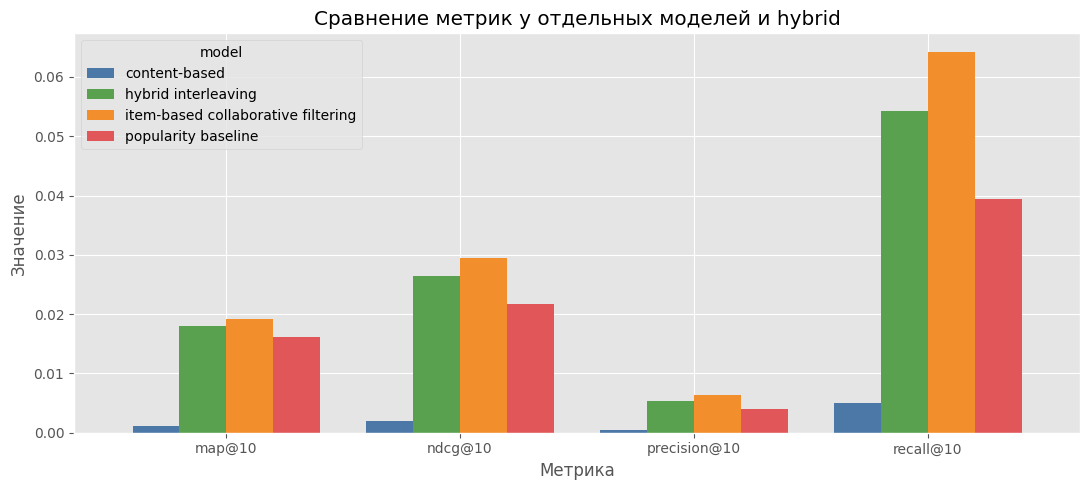

In [7]:
plot_df = comparison_df.melt(id_vars="model", var_name="metric", value_name="value")
plot_pivot = plot_df.pivot(index="metric", columns="model", values="value")

fig, ax = plt.subplots(figsize=(11, 5))
plot_pivot.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#4C78A8", "#59A14F", "#F28E2B", "#E15759"],
)
ax.set_title("Сравнение метрик у отдельных моделей и hybrid")
ax.set_xlabel("Метрика")
ax.set_ylabel("Значение")
ax.legend(title="model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Интерпретация результата

В этом запуске `hybrid interleaving` уже выглядит разумно: он не обогнал лучшую `item-based collaborative filtering` модель, но заметно улучшил результат относительно `popularity baseline`.

По `recall@10` и `precision@10` hybrid вышел на `0.0543` и `0.0054`. Это лучше, чем у `popularity baseline` (`0.0395` и `0.0039`), но всё ещё слабее, чем у чистой collaborative-модели (`0.0641` и `0.0064`).

Особенно полезно посмотреть на `MAP@10` и `NDCG@10`: hybrid получил `0.0180` и `0.0265`. Это почти уровень `item-based collaborative filtering` (`0.0191` и `0.0295`) и уже лучше, чем у `popularity baseline` (`0.0162` и `0.0218`). Значит, гибрид не только чаще находит релевантный объект, чем baseline, но и ранжирует его заметно аккуратнее.

Что было сделано, чтобы hybrid стал таким:

- сначала не просто меняли веса, а поменяли приоритет порядка: более сильная collaborative-модель теперь идёт раньше в каждом раунде interleaving;
- после этого уменьшили долю слабого `content-based` сигнала и оставили ему только аккуратную добавочную роль.

Практический вывод здесь такой:

- слишком агрессивное добавление слабого `content-based` сигнала действительно портит top-10;
- более осторожный hybrid может сохранить большую часть качества сильной collaborative-модели;
- при этом он остаётся не копией одной модели, а отдельным способом смешивания сигналов.

Для учебного notebook это хороший результат: видно, что hybrid не обязан быть лучшим по всем метрикам, но должен быть настроен так, чтобы не разрушать сильную компоненту и при этом добавлять второй источник сигнала аккуратно.


## Ограничения метода

Даже такой простой гибрид имеет ограничения:

- веса fusion выбраны вручную, а не обучены;
- если одна из компонент очень слабая, она может только шуметь;
- hybrid не отменяет cold-start ограничения исходных моделей;
- при большом числе моделей ранговое объединение нужно калибровать аккуратнее;
- offline улучшение гибрида не гарантирует product uplift без онлайн-проверки.


## Что получилось

После этого notebook должно быть понятно:

- зачем recommender systems комбинируют несколько моделей;
- как устроен простой hybrid на weighted interleaving;
- почему hybrid не обязан быть магически лучшим, чтобы быть полезным;
- как сравнивать hybrid с его компонентами;
- какие ограничения остаются даже после объединения нескольких сигналов.

Core-маршрут на этом этапе закрывает базовый путь: данные, baseline, content-based, collaborative filtering, метрики и hybrid-рекомендации.
